# Light Adaptation Clamp (LaC) Demo

This notebook demonstrates the Light Adaptation Clamp tool for photoreceptor
phototransduction modeling. It ports the MATLAB `demoMain.m` workflow to Python.

The key idea: given a **target linear response**, invert the full biophysical
model to find the **modified stimulus** that produces that linear response
through the nonlinear phototransduction cascade. This compensates for
adaptation and nonlinearities in the photoreceptor.

## Step 1: Initialize Model Parameters

Consensus biophysical parameters for the photoreceptor type. See the
[wiki](https://github.com/chrischen2/coneLinearization.wiki.git) for
mathematical details on the biophysical model.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter
from scipy.signal.windows import gaussian

from photoreceptor_linearization import (
    BiophysModel,
    InvertedModel,
    init_params,
    get_linear_coefficients,
)

model_type = "peripheral_primate_cone"
params = init_params(model_type)
print(f"Model type: {model_type}")
print(f"Dark current: {params.dark_current:.2f} pA")

Model type: peripheral_primate_cone
Dark current: 428.75 pA


## Step 2: Define Linear Model Coefficients

Pre-fitted coefficients of a linear model approximation to the full biophysical
model at a specific light level. The linear model has three parameters:
- **ScFact**: scaling factor
- **TauR**: rising time constant
- **TauD**: decaying time constant

In [3]:
coefficients = get_linear_coefficients(model_type, 5000)
print(f"Light level: 5000 R*/s")
print(f"  ScFact = {coefficients.sc_fact}")
print(f"  TauR   = {coefficients.tau_r}")
print(f"  TauD   = {coefficients.tau_d}")

Light level: 5000 R*/s
  ScFact = 1.655
  TauR   = 0.0152
  TauD   = 0.0181


## Step 3: Generate Stimuli

Set up common parameters and create three example stimuli:
1. **Sinusoid** — high-contrast sine wave (3 Hz)
2. **Noise** — smoothed Gaussian noise
3. **Flashes and step** — step change with brief flashes

In [4]:
# Common parameters
mean_intensity = 5000  # R*/s
smooth_pts = 100
num_pts = 100000
dt = params.time_step
time = np.arange(1, num_pts + 1) * dt
mean_flux = mean_intensity * dt

### Example 1: High-contrast sinusoid

In [5]:
sine_freq = 3  # Hz
stm_sine = (0.9 * np.sin(2 * np.pi * time * sine_freq) + 1) * mean_intensity
stm_sine[: num_pts // 2] = mean_intensity  # first half settles
stm_sine = stm_sine * dt

### Example 2: Smoothed Gaussian noise

In [6]:
rng = np.random.RandomState(1)  # matches MATLAB rng(1)
noise_raw = rng.normal(mean_flux, mean_flux * 5, num_pts)
win = gaussian(smooth_pts, std=(smooth_pts - 1) / 5.0)
# Smoothed noise already in R*/timestep units (generated from mean_flux = mean_intensity * dt)
stm_noise = lfilter(win, 1.0, noise_raw) / np.sum(win)
stm_noise[: num_pts // 2] = mean_flux  # settling period at mean

### Example 3: Flashes and step

In [7]:
flash_fact = 5       # brightness of flash relative to mean
step_fact = 2        # factor to change mean intensity
flash_duration = 10  # time points
flash_time = [num_pts // 2 - 3000, 3 * num_pts // 4 - 3000]

# Step
stm_flash = mean_intensity * np.ones(num_pts)
stm_flash[num_pts // 2 : 3 * num_pts // 4] = mean_intensity * step_fact

# Flashes
for ft in flash_time:
    stm_flash[ft : ft + flash_duration] += mean_intensity * flash_fact

stm_flash = stm_flash * dt

## Step 4: Model Inversion

For each stimulus:
1. Run the **full biophysical model** to get a reference response
2. Run the **linear model** to get the target (linearized) response
3. **Invert** the biophysical model to find the modified stimulus that produces the linear response through the full model

In [8]:
def run_inversion(stm, label):
    """Run biophysical + linear models and invert to find modified stimulus."""
    model = BiophysModel(params)
    inverter = InvertedModel(params)

    # Full biophysical response to original stimulus
    full_response = model.run_biophysical(stm, dt)

    # Linear response to original stimulus
    linear_response = model.run_linear(stm, dt, coefficients)
    # Align linear response to full response at the settling point
    linear_response = (
        linear_response
        - linear_response[num_pts // 4]
        + full_response[num_pts // 4]
    )

    # Invert: find stimulus that makes full model produce the linear response
    result = inverter.estimate_stimulus(
        target_response=linear_response,
        original_stimulus=stm,
        time_step=dt,
        smooth_pts=smooth_pts,
    )

    # Run full model with the modified stimulus to verify
    modified_response = model.run_biophysical(result.raw_estimate, dt)

    # Measure how well the modified stimulus linearizes the response
    # (compare modified response to target linear response, skip settling)
    start = num_pts // 2
    mse = np.mean((modified_response[start:] - linear_response[start:]) ** 2)
    var_lin = np.mean((linear_response[start:] - np.mean(linear_response[start:])) ** 2)
    r2 = 1.0 - mse / var_lin if var_lin > 0 else float("nan")
    print(f"{label}: modified-vs-linear R² = {r2:.4f}")

    return full_response, linear_response, modified_response, result


results_sine = run_inversion(stm_sine, "Sinusoid")
results_noise = run_inversion(stm_noise, "Noise")
results_flash = run_inversion(stm_flash, "Flashes & Step")

Sinusoid: modified-vs-linear R² = 1.0000
Noise: modified-vs-linear R² = 0.9996
Flashes & Step: modified-vs-linear R² = 0.9999


## Results

Left panels show original vs. modified (LaC-corrected) stimuli in R*/s.
Right panels show the full biophysical response to the original stimulus,
the target linear response, and the full model's response to the modified stimulus.

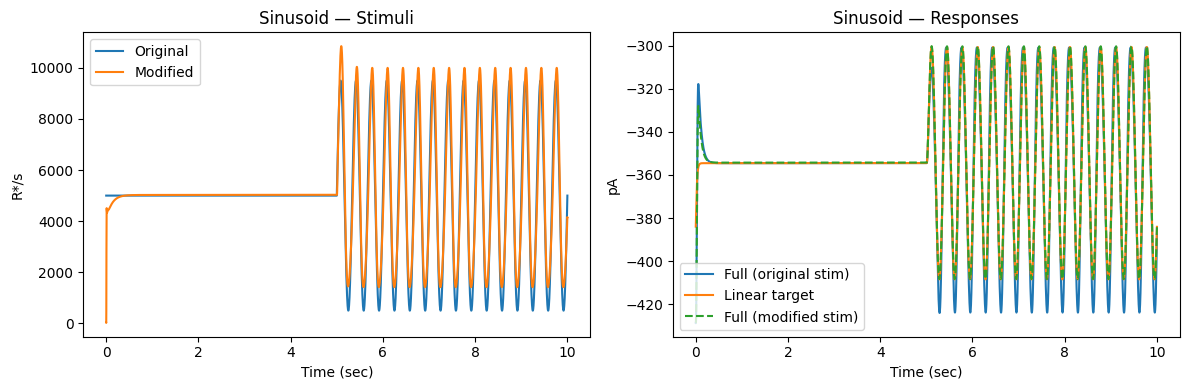

In [9]:
def plot_results(stm, full_resp, linear_resp, modified_resp, result, title):
    """Plot stimuli and responses side by side."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(time, stm / dt, linewidth=1.5, label="Original")
    ax1.plot(time, result.estimate, linewidth=1.5, label="Modified")
    ax1.set_xlabel("Time (sec)")
    ax1.set_ylabel("R*/s")
    ax1.set_title(f"{title} — Stimuli")
    ax1.legend()

    ax2.plot(time, full_resp, linewidth=1.5, label="Full (original stim)")
    ax2.plot(time, linear_resp, linewidth=1.5, label="Linear target")
    ax2.plot(time, modified_resp, linewidth=1.5, linestyle="--", label="Full (modified stim)")
    ax2.set_xlabel("Time (sec)")
    ax2.set_ylabel("pA")
    ax2.set_title(f"{title} — Responses")
    ax2.legend()

    plt.tight_layout()
    plt.show()


# Example 1: Sinusoid
full_resp, lin_resp, mod_resp, inv_result = results_sine
plot_results(stm_sine, full_resp, lin_resp, mod_resp, inv_result, "Sinusoid")

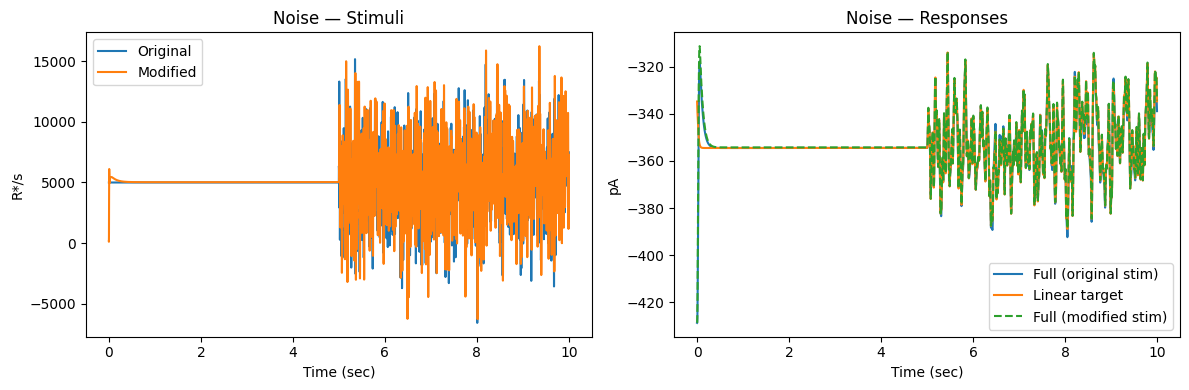

In [10]:
# Example 2: Noise
full_resp, lin_resp, mod_resp, inv_result = results_noise
plot_results(stm_noise, full_resp, lin_resp, mod_resp, inv_result, "Noise")

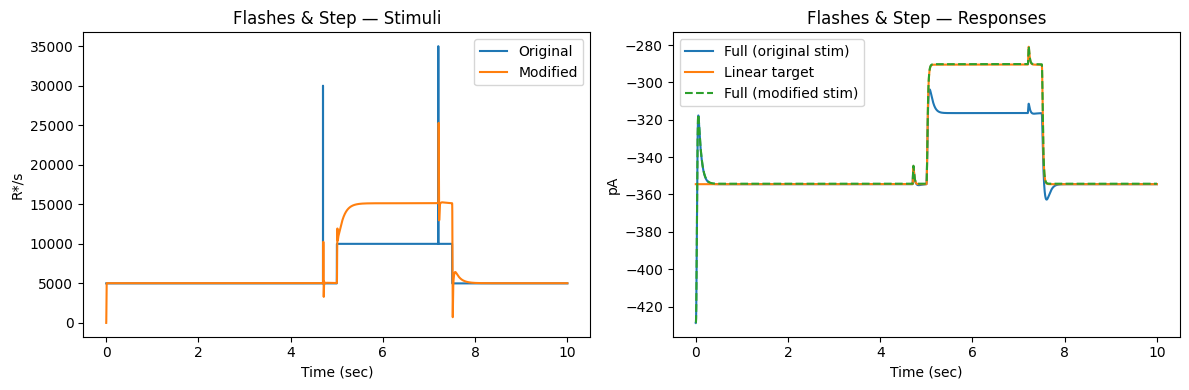

In [11]:
# Example 3: Flashes and Step
full_resp, lin_resp, mod_resp, inv_result = results_flash
plot_results(stm_flash, full_resp, lin_resp, mod_resp, inv_result, "Flashes & Step")